## Notebook 06 — Drawdown Analysis

### Crypto Alpha Research Lab (CARL)

This notebook evaluates downside risk through drawdown analysis. Unlike volatility, which measures return dispersion, drawdown quantifies cumulative portfolio losses relative to previous wealth peaks. Maximum drawdown is a widely used risk metric in quantitative finance because it captures the magnitude and persistence of adverse market movements experienced by investors.

### Research Objective

The objectives of this notebook are to:

- Construct the cumulative wealth index.
- Estimate the running peak of portfolio value.
- Compute the drawdown series.
- Measure maximum drawdown.
- Visualize periods of severe market stress.

In [2]:
TICKER = "BTC-USD"

START_DATE = "2020-01-01"
END_DATE = "2026-06-20"

INTERVAL = "1d"

AUTO_ADJUST = True

REFRESH_CACHE = True

In [3]:
import matplotlib.pyplot as plt

from crypto_alpha_lab.data.storage import load_prices

In [5]:
btc = load_prices(
    ticker="BTC-USD",
    start="2020-01-01",
    end="2026-06-20",
    interval="1d",
)

btc.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


The cumulative wealth index transforms daily returns into the growth trajectory of a one-unit investment. This representation allows subsequent evaluation of capital preservation by comparing current portfolio value against historical peaks, providing the foundation for drawdown analysis.

In [6]:
btc["Return"] = btc["Close"].pct_change()

btc["Wealth_Index"] = (1 + btc["Return"]).cumprod()

btc["Running_Max"] = btc["Wealth_Index"].cummax()

btc["Drawdown"] = (
    btc["Wealth_Index"] - btc["Running_Max"]
) / btc["Running_Max"]

In [7]:
max_drawdown = btc["Drawdown"].min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -76.63%


The running maximum represents the highest portfolio value achieved up to each observation date. It establishes the benchmark against which subsequent losses are measured, enabling the identification of periods characterized by capital erosion.

Drawdown measures the percentage decline from the historical peak in portfolio value. Unlike return volatility, drawdown directly reflects the cumulative losses experienced by investors and therefore provides a more intuitive measure of downside risk.

Maximum drawdown represents the largest peak-to-trough decline observed during the sample period. This statistic summarizes the most severe capital loss an investor would have experienced before a subsequent recovery and serves as a standard downside risk metric in portfolio management.

### Interpretation

The drawdown profile provides a direct assessment of downside investment risk over the sample period. Persistent negative drawdowns indicate prolonged recovery phases following market corrections, while rapid reversions toward zero suggest efficient recovery from adverse shocks. Combined with the volatility analysis presented previously, drawdown offers a complementary perspective on market risk by emphasizing realized capital losses rather than return dispersion alone.

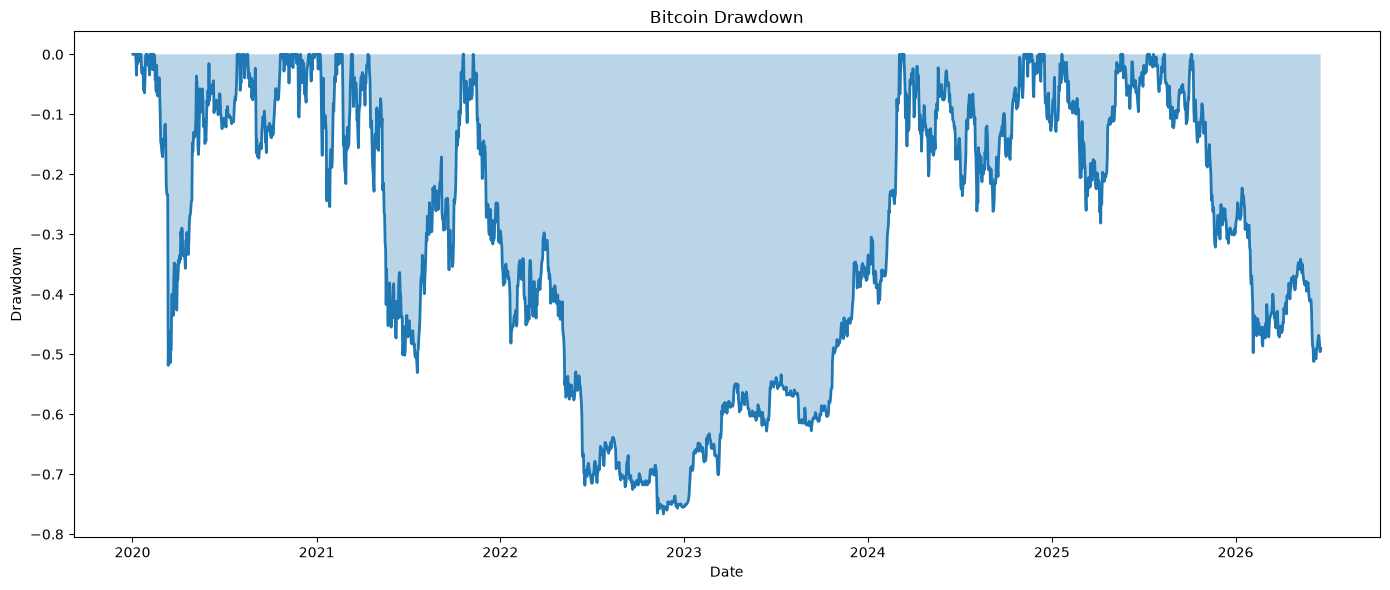

In [8]:
plt.figure(figsize=(14, 6))

plt.plot(
    btc.index,
    btc["Drawdown"],
    linewidth=2,
)

plt.fill_between(
    btc.index,
    btc["Drawdown"],
    0,
    alpha=0.3,
)

plt.title("Bitcoin Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.tight_layout()
plt.show()

In [9]:
btc["Drawdown"].describe()

count    2361.000000
mean       -0.295229
std         0.233906
min        -0.766346
25%        -0.474154
50%        -0.249631
75%        -0.082678
max         0.000000
Name: Drawdown, dtype: float64

### Interpretation

The drawdown analysis indicates that Bitcoin experienced substantial and persistent downside risk over the sample period. The maximum drawdown reached approximately **76.6%**, reflecting a severe peak-to-trough decline during the 2022–2023 market downturn, while the average drawdown of **29.5%** suggests that the asset traded below its historical peak for a considerable portion of the observation period. The median drawdown (**25.0%**) and relatively high dispersion (standard deviation **23.4%**) further highlight the frequency and variability of capital losses. Although Bitcoin recovered to new highs by early 2025, the renewed drawdowns exceeding **50%** toward the end of the sample reinforce its high-risk profile and demonstrate the value of drawdown analysis as a complementary measure to return volatility when assessing downside investment risk.